<a href="https://colab.research.google.com/github/sbrgothub/Turkey_Online_Retail_New/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Churn Prediction (Customer)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/luminar/data_science/resume/archive (1)/ecommerce_customer_behavior_dataset_v2.csv')

In [ ]:
df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


In [ ]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City',
       'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount',
       'Total_Amount', 'Payment_Method', 'Device_Type',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer',
       'Delivery_Time_Days', 'Customer_Rating'],
      dtype='object')

In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
df.dtypes

,0
Order_ID,object
Customer_ID,object
Date,datetime64[ns]
Age,int64
Gender,object
City,object
Product_Category,object
Unit_Price,float64
Quantity,int64
Discount_Amount,float64


# BG/NBD model

raw Input

In [ ]:
raw_inp=df.copy()

Bg/Nbd input format conversion

In [ ]:
raw_inp

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


*   Training set: All trans before 2023
*   Testing set: All trans after 2024

Filter Customers common in both 2023 and 2024.
> Reason: to check predicted value for customers (year 2024) match actual value of same customers trained at year 2023

In [ ]:
required_customers=set(raw_inp.loc[raw_inp['Date'].dt.year<=2023,'Customer_ID']).intersection(set(raw_inp.loc[raw_inp['Date'].dt.year>=2024,'Customer_ID']))
raw_inp=raw_inp.loc[raw_inp['Customer_ID'].isin(required_customers)]

Train Test split

In [ ]:
raw_inp_train=raw_inp.loc[raw_inp['Date'].dt.year<=2023]
raw_inp_test=raw_inp.loc[raw_inp['Date'].dt.year>=2024]

In [ ]:
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 11.7 MB/s eta 0:00:00


Convert to BG/NBD input format(recency,frequency,monetary value)

In [ ]:
from lifetimes.utils import summary_data_from_transaction_data
# This one line does 100% of the manual math automatically
rfm_matrix = summary_data_from_transaction_data(
    raw_inp_train,
    customer_id_col='Customer_ID',
    datetime_col='Date',
    monetary_value_col='Total_Amount',
    observation_period_end=raw_inp_train['Date'].max() # Your analysis cutoff date
)

Analyse

In [ ]:
analyser=rfm_matrix.copy()
analyser=analyser.reset_index()
analyser['Customer_ID']

,Customer_ID
0,CUST_00003
1,CUST_00010
2,CUST_00011
3,CUST_00013
4,CUST_00016
...,...
2107,CUST_04989
2108,CUST_04992
2109,CUST_04993
2110,CUST_04996


In [ ]:
dt_store={'fr':{},'rc_t':{}}
for j in set(analyser['Customer_ID']):
  lock=analyser.loc[analyser['Customer_ID']==j]
  fr=lock['frequency'].values[0]
  rc_t=lock['T'].values[0]-lock['recency'].values[0]
  if fr not in dt_store['fr'].values():
    dt_store['fr'][j]=fr
  if rc_t not in dt_store['rc_t'].values():
    dt_store['rc_t'][j]=rc_t

# sorted_data = dict(sorted(dt_store.items(), key=lambda item: item[1]))

In [ ]:
dt_store['fr']=dict(sorted(dt_store['fr'].items(),key=lambda item:item[1]))

In [ ]:
dt_store['rc_t']=dict(sorted(dt_store['rc_t'].items(),key=lambda item:item[1]))

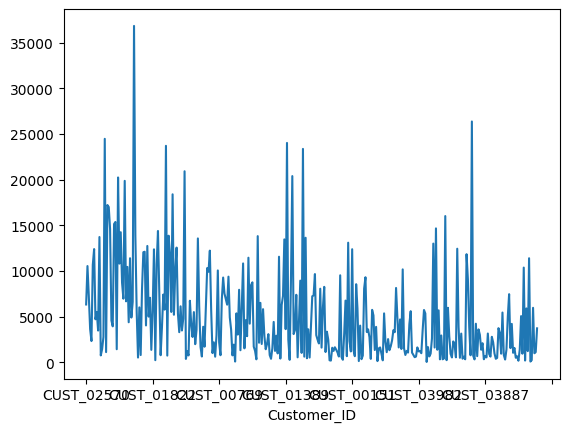

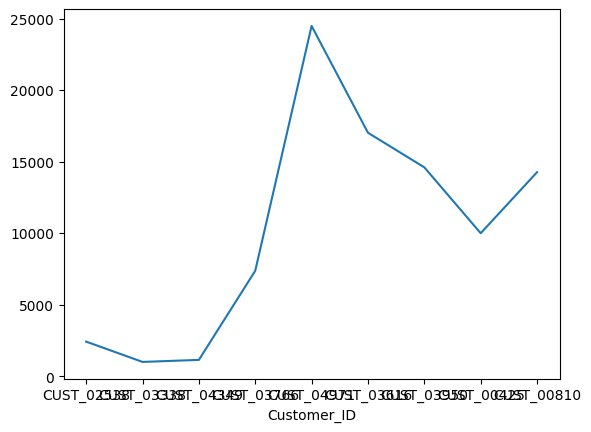

In [ ]:
cnt=0
ploter=df.copy()
for i in ['rc_t','fr']:
  customer= dt_store[i].keys()
  ploter=ploter.loc[ploter['Customer_ID'].isin(customer)]
  ploter.groupby('Customer_ID',observed=False)['Total_Amount'].sum().reindex(customer).plot(kind='line')
  plt.show()

Training

In [ ]:
from lifetimes import BetaGeoFitter
bgf = BetaGeoFitter(penalizer_coef=0.1)

bgf.fit(
    rfm_matrix['frequency'],
    rfm_matrix['recency'],
    rfm_matrix['T']
)

<lifetimes.BetaGeoFitter: fitted with 2112 subjects, a: 0.00, alpha: 106.64, b: 0.00, r: 0.92>

In [ ]:
# Predict purchases for the next 30 days
t = 30
bgf.conditional_expected_number_of_purchases_up_to_time(
    t,
    rfm_matrix['frequency'],
    rfm_matrix['recency'],
    rfm_matrix['T']
)

,0
Customer_ID,
CUST_00003,0.067078
CUST_00010,0.236042
CUST_00011,0.395420
CUST_00013,0.064281
CUST_00016,0.463054
...,...
CUST_04989,0.191317
CUST_04992,0.074659
CUST_04993,0.397960


In [ ]:
# Customer "Aliveness" Probability
bgf.conditional_probability_alive(
    rfm_matrix['frequency'],
    rfm_matrix['recency'],
    rfm_matrix['T']
)


array([1., 1., 1., ..., 1., 1., 1.])

In [ ]:
a=df[df['Customer_ID']=='CUST_00001'].copy()
a

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4


In [ ]:
from lifetimes import GammaGammaFitter

returning_customers = rfm_matrix[
    (rfm_matrix['frequency'] > 0) &
    (rfm_matrix['monetary_value'] > 0)
].copy()


# 2. Train the Gamma-Gamma Model
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers['frequency'], returning_customers['monetary_value'])

<lifetimes.GammaGammaFitter: fitted with 1650 subjects, p: 3.43, q: 0.25, v: 3.31>

Revnue generated for 90 days

In [ ]:
# 1. Calculate 90-day expected purchases (Your existing step)
t = 90
no_of_purchase = bgf.conditional_expected_number_of_purchases_up_to_time(
    t,
    rfm_matrix['frequency'],
    rfm_matrix['recency'],
    rfm_matrix['T']
)

# 2. Get the "smoothed" expected transaction value from Gamma-Gamma
# This automatically assigns a realistic store-average spend to your 0-frequency buyers
expected_avg_spend = ggf.conditional_expected_average_profit(
    rfm_matrix['frequency'],
    rfm_matrix['monetary_value']
)

# 3. Multiply the two for a statistically sound revenue projection
money = no_of_purchase * expected_avg_spend

Validation

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
money=money.reset_index()

In [ ]:
money

,Customer_ID,0
0,CUST_00003,-3.061702
1,CUST_00010,497.426127
2,CUST_00011,1671.002389
3,CUST_00013,-2.934026
4,CUST_00016,1420.830646
...,...,...
2107,CUST_04989,1525.515130
2108,CUST_04992,-3.407708
2109,CUST_04993,1248.259722
2110,CUST_04996,1249.130262


In [ ]:
customer_ord=money['Customer_ID'].values
lock=df.loc[df['Customer_ID'].isin(customer_ord)]
actual=lock.groupby('Customer_ID',observed=False)['Total_Amount'].sum().reindex(customer_ord).reset_index()

In [ ]:
mae = mean_absolute_error(actual['Total_Amount'], money[0])
rmse = np.sqrt(mean_squared_error(actual['Total_Amount'], money[0]))
r2 = r2_score(actual['Total_Amount'], money[0])

In [ ]:
mae,rmse,r2

(4956.449598664278, np.float64(7045.929867508792), -0.38798282882783575)

Too much wrong predictions
*   solution: Cap extreme outliers at the 98th percentile


In [ ]:
rfm_matrix_capped=rfm_matrix.copy()
customers_filter = rfm_matrix_capped[rfm_matrix_capped['frequency']>0]

In [ ]:
monetary_cap = customers_filter['monetary_value'].quantile(0.98)
rfm_matrix_capped['monetary_value'] = rfm_matrix_capped['monetary_value'].clip(upper=monetary_cap)

In [ ]:
train_data = rfm_matrix_capped[
    (rfm_matrix_capped['frequency'] > 0) & (rfm_matrix_capped['monetary_value'] > 0)
].copy()

In [ ]:
ggf_update= GammaGammaFitter(penalizer_coef=0.01)
ggf_update.fit(train_data['frequency'],train_data['monetary_value'])

<lifetimes.GammaGammaFitter: fitted with 1650 subjects, p: 3.44, q: 0.25, v: 3.32>

In [ ]:
expected_avg_spend_updated = ggf_update.conditional_expected_average_profit(
    rfm_matrix_capped['frequency'],
    rfm_matrix_capped['monetary_value']
)

In [ ]:
rfm_matrix_capped.isna().sum()

,0
frequency,0
recency,0
T,0
monetary_value,0


In [ ]:
money_updated = no_of_purchase * expected_avg_spend_updated

# Convert series to DataFrame with clean column names
money_updated = money_updated.reset_index()
money_updated.columns = ['Customer_ID', 'predicted_amount']


In [ ]:
money_updated.isna().sum()

,0
Customer_ID,0
predicted_amount,0


In [ ]:
customer_ord_updated = money_updated['Customer_ID'].values
lock = df.loc[df['Customer_ID'].isin(customer_ord_updated)]

In [ ]:
actual = lock.groupby('Customer_ID', observed=False)['Total_Amount'].sum()
actual = actual.reindex(customer_ord_updated, fill_value=0).reset_index()
actual.columns = ['Customer_ID', 'actual_amount']

In [ ]:
mae = mean_absolute_error(actual['actual_amount'], money_updated['predicted_amount'])
rmse = np.sqrt(mean_squared_error(actual['actual_amount'], money_updated['predicted_amount']))
r2 = r2_score(actual['actual_amount'], money_updated['predicted_amount'])

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")


MAE: 5002.1846, RMSE: 7127.6986, R2: -0.4204
